In [1]:
#imports
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import random, torch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
import pandas as pd

TARGET_N = 1000


df = pd.read_excel("train_binary.xlsx")

# Stratify
df_small = (
    df.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(
          n=round(len(x) / len(df) * TARGET_N),
          random_state=SEED
      ))
      .reset_index(drop=True)
)

df_small = df_small.sample(frac=1, random_state=SEED).reset_index(drop=True)

output_path = f"train_binary_{TARGET_N}.xlsx"
df_small.to_excel(output_path, index=False)

print("Original distribution:")
print(df["label"].value_counts(normalize=True))

print("\nNew distribution:")
print(df_small["label"].value_counts(normalize=True))

print("\nSaved:", output_path)

Original distribution:
label
1    0.857636
0    0.142364
Name: proportion, dtype: float64

New distribution:
label
1    0.858
0    0.142
Name: proportion, dtype: float64

Saved: train_binary_1000.xlsx


C:\Users\Mohammad Pashaei\AppData\Local\Temp\ipykernel_11828\71885171.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [4]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(
        224, scale=(0.7, 1.0),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [5]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset

class ISICBinaryDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, image_id):
        base = os.path.join(self.images_dir, str(image_id))
        for ext in [".jpg"]:
            p = base + ext
            if os.path.isfile(p):
                return p
        if os.path.isfile(base):  
            return base
        raise FileNotFoundError(f"Image '{image_id}' not found in {self.images_dir}")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self._resolve_path(row["image"])
        y = int(row["label"])   # 0=MEL, 1=NV 

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(y, dtype=torch.long)

In [6]:
import pandas as pd

train_df = pd.read_excel("train_binary_1000.xlsx")
val_df   = pd.read_excel("val_binary.xlsx")
test_df  = pd.read_excel("test_binary.xlsx")

print(train_df.head())
print(val_df.head())
print(test_df.head())
print(train_df.shape, val_df.shape, test_df.shape)


          image  label
0  ISIC_0030588      1
1  ISIC_0025861      1
2  ISIC_0031555      1
3  ISIC_0031193      1
4  ISIC_0026658      1
          image  label
0  ISIC_0034321      1
1  ISIC_0034322      1
2  ISIC_0034324      1
3  ISIC_0034325      1
4  ISIC_0034328      1
          image  label
0  ISIC_0034524      1
1  ISIC_0034525      1
2  ISIC_0034527      1
3  ISIC_0034528      1
4  ISIC_0034529      0
(1000, 2) (144, 2) (1080, 2)


In [7]:
train_ds = ISICBinaryDataset(train_df, images_dir="train", transform=train_tfms)
val_ds   = ISICBinaryDataset(val_df,   images_dir="val",   transform=val_tfms)
test_ds  = ISICBinaryDataset(test_df,  images_dir="test",  transform=val_tfms)

In [8]:
x, y = train_ds[4]
print(x.shape, y.item())

torch.Size([3, 224, 224]) 1


In [9]:
import pandas as pd


def show_counts(df, name):
    counts = df["label"].value_counts().sort_index()
    mel = int(counts.get(0, 0))
    nv  = int(counts.get(1, 0))
    total = mel + nv
    print(f"\n{name}:")
    print(f"  MEL (0): {mel}  ({mel/total:.3f})")
    print(f"  NV  (1): {nv}   ({nv/total:.3f})")
    print(f"  Total : {total}")

show_counts(train_df, "TRAIN")
show_counts(val_df,   "VAL")
show_counts(test_df,  "TEST")


TRAIN:
  MEL (0): 142  (0.142)
  NV  (1): 858   (0.858)
  Total : 1000

VAL:
  MEL (0): 21  (0.146)
  NV  (1): 123   (0.854)
  Total : 144

TEST:
  MEL (0): 171  (0.158)
  NV  (1): 909   (0.842)
  Total : 1080


In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,         
    num_workers=0,
    pin_memory=True
)

val_loader  = DataLoader(val_ds,  batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

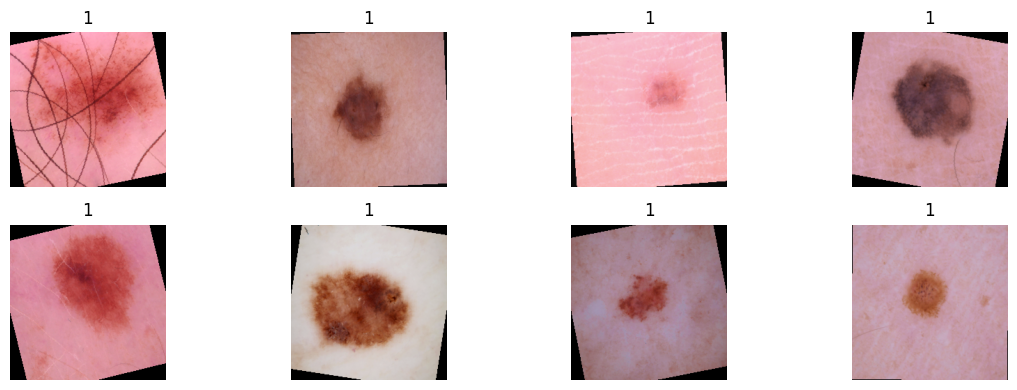

In [11]:
#debug aug
import matplotlib.pyplot as plt
import torch

mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
std  = torch.tensor(IMAGENET_STD).view(3,1,1)

def show_batch(dataloader, n=8):
    imgs, labels = next(iter(dataloader))
    imgs = imgs[:n].cpu()
    labels = labels[:n].cpu()

    # unnormalize for display
    imgs = imgs * std + mean
    imgs = imgs.clamp(0, 1)

    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(2, n//2, i+1)
        plt.imshow(imgs[i].permute(1,2,0))
        plt.title(int(labels[i]))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, n=8)

In [12]:
imgs, labels = next(iter(train_loader))
print(imgs.shape, labels[:])

torch.Size([8, 3, 224, 224]) tensor([1, 1, 1, 1, 1, 1, 1, 1])


[Batch, Channels, Height, Width]

In [13]:
imgs, labels = next(iter(test_loader))
print(imgs.shape, labels[:])

torch.Size([8, 3, 224, 224]) tensor([1, 1, 1, 1, 0, 1, 1, 1])


In [14]:
imgs, labels = next(iter(val_loader))
print(imgs.shape, labels[:])

torch.Size([8, 3, 224, 224]) tensor([1, 1, 1, 1, 1, 0, 1, 1])


In [15]:
#pre train resnet18
import torchvision.models as models
import torch.nn as nn
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#===========model============
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1) 
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)



# Freeze 
for p in model.parameters():
    p.requires_grad = False

# Unfreeze fc
for p in model.fc.parameters():
    p.requires_grad = True

# Unfreeze layer4 
for p in model.layer4[1].parameters():
    p.requires_grad = True

In [16]:
#freeze all layers and only train the final fc layer
"""
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
"""

'\nfor param in model.parameters():\n    param.requires_grad = True\n\noptimizer = torch.optim.Adam(model.parameters(), lr=1e-4)\n'

In [17]:
#leakage
train_ids = set(train_df["image"].astype(str))
val_ids   = set(val_df["image"].astype(str))
test_ids  = set(test_df["image"].astype(str))

print("train∩val :", len(train_ids & val_ids))
print("train∩test:", len(train_ids & test_ids))
print("val∩test  :", len(val_ids & test_ids))

train∩val : 0
train∩test: 0
val∩test  : 0


In [18]:
print("Trainable params:")
for n,p in model.named_parameters():
    if p.requires_grad:
        print(" ", n)

Trainable params:
  layer4.1.conv1.weight
  layer4.1.bn1.weight
  layer4.1.bn1.bias
  layer4.1.conv2.weight
  layer4.1.bn2.weight
  layer4.1.bn2.bias
  fc.weight
  fc.bias


In [19]:
def set_trainable_train_mode(model):
    model.eval()  
    model.layer4.train()  
    model.fc.train()      

Device: cuda
Trainable params:
  layer4.1.conv1.weight
  layer4.1.bn1.weight
  layer4.1.bn1.bias
  layer4.1.conv2.weight
  layer4.1.bn2.weight
  layer4.1.bn2.bias
  fc.weight
  fc.bias
Epoch 01/15 | Train loss=0.5228 balAcc=0.713 | Val loss=0.2680 balAcc=0.840
Epoch 02/15 | Train loss=0.4090 balAcc=0.800 | Val loss=0.5637 balAcc=0.780
Epoch 03/15 | Train loss=0.3866 balAcc=0.815 | Val loss=0.3113 balAcc=0.848
Epoch 04/15 | Train loss=0.3484 balAcc=0.821 | Val loss=0.2582 balAcc=0.880
Epoch 05/15 | Train loss=0.2889 balAcc=0.878 | Val loss=0.3229 balAcc=0.863
Epoch 06/15 | Train loss=0.2823 balAcc=0.866 | Val loss=0.2866 balAcc=0.907
Epoch 07/15 | Train loss=0.2822 balAcc=0.868 | Val loss=0.2512 balAcc=0.911
Epoch 08/15 | Train loss=0.2481 balAcc=0.891 | Val loss=0.2602 balAcc=0.883
Epoch 09/15 | Train loss=0.1966 balAcc=0.911 | Val loss=0.2742 balAcc=0.923
Epoch 10/15 | Train loss=0.1957 balAcc=0.918 | Val loss=0.2672 balAcc=0.868
Epoch 11/15 | Train loss=0.2324 balAcc=0.906 | Val loss

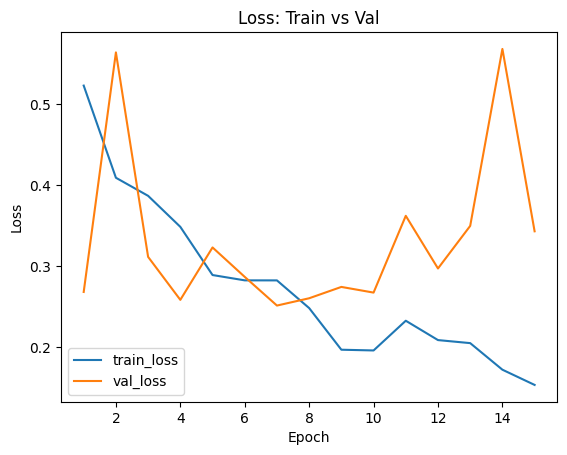

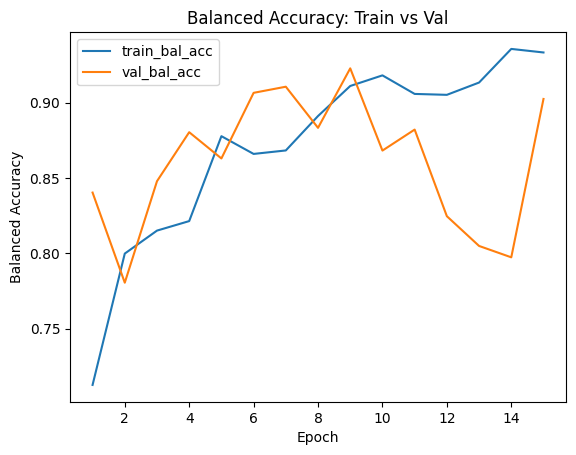

In [20]:
import copy
import numpy as np
import torch
import torch.nn as nn

from sklearn.metrics import balanced_accuracy_score

# -----------------------
# Config
# -----------------------
EPOCHS = 15
LR = 1e-4  
BEST_BY = "bal_acc"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# -----------------------
# Model

# -----------------------
import torchvision.models as models

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(DEVICE)

# -----------------------
# Freeze / Unfreeze: 
# -----------------------
for p in model.parameters():
    p.requires_grad = False

for p in model.fc.parameters():
    p.requires_grad = True

for p in model.layer4[1].parameters():
    p.requires_grad = True

print("Trainable params:")
for n, p in model.named_parameters():
    if p.requires_grad:
        print(" ", n)

# -----------------------
# Loss 
# -----------------------
y_train = train_df["label"].values
class_counts = np.bincount(y_train, minlength=2)

w0 = 1.0 / max(class_counts[0], 1)  # MEL
w1 = 1.0 / max(class_counts[1], 1)  # NV

weights = torch.tensor([w0, w1], dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)

# -----------------------
# Optimizer: 
# -----------------------
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

# -----------------------
# Metric 
# -----------------------
def compute_metrics(y_true, y_pred):
    return {"bal_acc": balanced_accuracy_score(y_true, y_pred)}

@torch.no_grad()
def run_eval(model, loader):
    model.eval()
    total_loss = 0.0
    ys, ps = [], []

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1)
        ys.append(labels.detach().cpu().numpy())
        ps.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(ys) if len(ys) else np.array([])
    y_pred = np.concatenate(ps) if len(ps) else np.array([])

    m = compute_metrics(y_true, y_pred) if len(y_true) else {"bal_acc": float("nan")}
    m["loss"] = total_loss / len(loader.dataset)
    return m, y_true, y_pred

def run_train_one_epoch(model, loader):
  
    model.eval()              
    model.layer4[1].train()     
    model.fc.train()            

    total_loss = 0.0
    ys, ps = [], []

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1)
        ys.append(labels.detach().cpu().numpy())
        ps.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(ys) if len(ys) else np.array([])
    y_pred = np.concatenate(ps) if len(ps) else np.array([])

    m = compute_metrics(y_true, y_pred) if len(y_true) else {"bal_acc": float("nan")}
    m["loss"] = total_loss / len(loader.dataset)
    return m

# -----------------------
# Training loop
# -----------------------
history = []
best_score = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr = run_train_one_epoch(model, train_loader)
    va, _, _ = run_eval(model, val_loader)

    history.append({"epoch": epoch, "train": tr, "val": va})

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train loss={tr['loss']:.4f} balAcc={tr['bal_acc']:.3f} | "
        f"Val loss={va['loss']:.4f} balAcc={va['bal_acc']:.3f}"
    )

    score = va[BEST_BY]
    if score > best_score:
        best_score = score
        best_state = copy.deepcopy(model.state_dict())

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nLoaded best model by {BEST_BY} = {best_score:.4f}")

# -----------------------
# Save best
# -----------------------
save_path = "best_resnet18_fc_layer4_1_balacc.pth"
torch.save(model.state_dict(), save_path)
print("Saved model weights to:", save_path)

# -----------------------
# Plot history (اختیاری)
# -----------------------
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history]
train_loss = [h["train"]["loss"] for h in history]
val_loss   = [h["val"]["loss"] for h in history]
train_bal  = [h["train"]["bal_acc"] for h in history]
val_bal    = [h["val"]["bal_acc"] for h in history]

plt.figure()
plt.plot(epochs, train_loss, label="train_loss")
plt.plot(epochs, val_loss, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss: Train vs Val")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_bal, label="train_bal_acc")
plt.plot(epochs, val_bal, label="val_bal_acc")
plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy: Train vs Val")
plt.legend()
plt.show()

In [21]:
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nLoaded best model by {BEST_BY} = {best_score:.4f}")


Loaded best model by bal_acc = 0.9228


In [22]:
# -----------------------
# Final Test 
# -----------------------
test_metrics, y_true, y_pred = run_eval(model, test_loader)

print("\nTEST RESULTS")
print(f"Test loss = {test_metrics['loss']:.4f}")
print(f"Test Balanced Accuracy = {test_metrics['bal_acc']:.4f}")


TEST RESULTS
Test loss = 0.6104
Test Balanced Accuracy = 0.7982


In [23]:
!jupyter nbconvert --to script LP-v5.ipynb

[NbConvertApp] Converting notebook LP-v5.ipynb to script
[NbConvertApp] Writing 42029 bytes to LP-v5.py


Device: cuda
Shapes: (100, 2) (144, 2) (1080, 2)

Trainable params:
  features.12.0.weight
  features.12.1.weight
  features.12.1.bias
  classifier.0.weight
  classifier.0.bias
  classifier.3.weight
  classifier.3.bias

===== TRAINING =====
Epoch 01/15 | Train loss=0.7090 balAcc=0.546 f1=0.755 | Val loss=0.5908 balAcc=0.674 f1=0.933
Epoch 02/15 | Train loss=0.5587 balAcc=0.711 f1=0.848 | Val loss=0.5698 balAcc=0.717 f1=0.914
Epoch 03/15 | Train loss=0.5735 balAcc=0.664 f1=0.828 | Val loss=0.5515 balAcc=0.729 f1=0.905
Epoch 04/15 | Train loss=0.5059 balAcc=0.865 f1=0.885 | Val loss=0.5430 balAcc=0.733 f1=0.909
Epoch 05/15 | Train loss=0.4394 balAcc=0.870 f1=0.927 | Val loss=0.5359 balAcc=0.721 f1=0.895
Epoch 06/15 | Train loss=0.3629 balAcc=0.870 f1=0.927 | Val loss=0.5258 balAcc=0.697 f1=0.892
Epoch 07/15 | Train loss=0.3822 balAcc=0.811 f1=0.929 | Val loss=0.5144 balAcc=0.701 f1=0.896
Epoch 08/15 | Train loss=0.3579 balAcc=0.858 f1=0.947 | Val loss=0.5032 balAcc=0.752 f1=0.884
Epoch 0

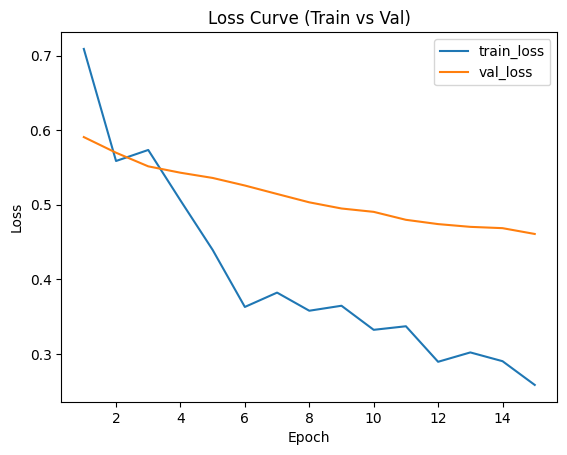

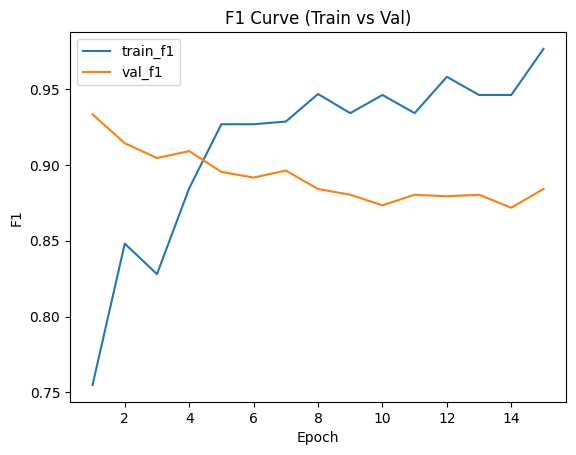

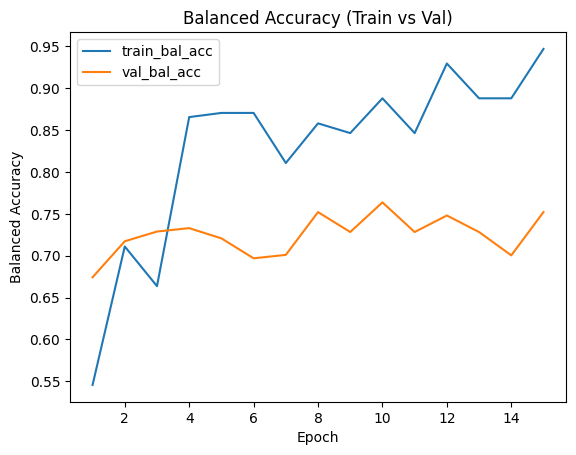


===== FINAL TEST (best model) =====
Test loss=0.5486
Test balAcc=0.7254
Test F1=0.8706

Confusion Matrix (rows=true, cols=pred):
[[107  64]
 [159 750]]

Classification Report:
              precision    recall  f1-score   support

      class0     0.4023    0.6257    0.4897       171
      class1     0.9214    0.8251    0.8706       909

    accuracy                         0.7935      1080
   macro avg     0.6618    0.7254    0.6801      1080
weighted avg     0.8392    0.7935    0.8103      1080



In [24]:


import os
import random
import copy
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image

import torchvision.models as models
from torchvision import transforms
from torchvision.transforms import InterpolationMode

import matplotlib.pyplot as plt

from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# -----------------------
# Reproducibility
# -----------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# -----------------------
# Config
# -----------------------
EPOCHS = 15
LR = 1e-4
BATCH_SIZE = 8
BEST_BY = "bal_acc"      
USE_LARGE = False        
POS_LABEL_FOR_F1 = 1     
# -----------------------
# Transforms
# -----------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(
        224, scale=(0.7, 1.0),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# -----------------------
# Dataset
# -----------------------
class ISICBinaryDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, image_id):
        base = os.path.join(self.images_dir, str(image_id))
        for ext in [".jpg"]:
            p = base + ext
            if os.path.isfile(p):
                return p
        if os.path.isfile(base):
            return base
        raise FileNotFoundError(f"Image '{image_id}' not found in {self.images_dir}")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self._resolve_path(row["image"])
        y = int(row["label"])  # 0/1

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(y, dtype=torch.long)

# -----------------------
# Load splits
# -----------------------
train_df = pd.read_excel("train_binary_100.xlsx")
val_df   = pd.read_excel("val_binary.xlsx")
test_df  = pd.read_excel("test_binary.xlsx")

print("Shapes:", train_df.shape, val_df.shape, test_df.shape)

# -----------------------
# Datasets / Loaders
# -----------------------
train_ds = ISICBinaryDataset(train_df, images_dir="train", transform=train_tfms)
val_ds   = ISICBinaryDataset(val_df,   images_dir="val",   transform=val_tfms)
test_ds  = ISICBinaryDataset(test_df,  images_dir="test",  transform=val_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# -----------------------
# Model: MobileNetV3 (Small/Large) pretrained
# -----------------------
if USE_LARGE:
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
else:
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, 2)
model = model.to(DEVICE)

# -----------------------
# Freeze / Unfreeze
# -----------------------
for p in model.parameters():
    p.requires_grad = False

# Unfreeze 
for p in model.classifier.parameters():
    p.requires_grad = True

# Unfreeze 
for p in model.features[-1].parameters():
    p.requires_grad = True

print("\nTrainable params:")
for n, p in model.named_parameters():
    if p.requires_grad:
        print(" ", n)


# Loss:

y_train = train_df["label"].values
class_counts = np.bincount(y_train, minlength=2)

w0 = 1.0 / max(class_counts[0], 1)
w1 = 1.0 / max(class_counts[1], 1)
weights = torch.tensor([w0, w1], dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)

# -----------------------
# Optimizer (trainable only)
# -----------------------
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

# -----------------------
# Train/Eval 
# -----------------------
@torch.no_grad()
def eval_metrics(model, loader):
    model.eval()
    total_loss = 0.0
    ys, ps = [], []

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1)
        ys.append(labels.detach().cpu().numpy())
        ps.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(ys) if len(ys) else np.array([])
    y_pred = np.concatenate(ps) if len(ps) else np.array([])

    out = {}
    out["loss"] = total_loss / len(loader.dataset)
    out["bal_acc"] = balanced_accuracy_score(y_true, y_pred) if len(y_true) else float("nan")
    out["f1"] = f1_score(
        y_true, y_pred,
        average="binary",
        pos_label=POS_LABEL_FOR_F1,
        zero_division=0
    ) if len(y_true) else float("nan")

    return out, y_true, y_pred

def train_one_epoch(model, loader):
   
    model.eval()
    model.classifier.train()
    model.features[-1].train()

    total_loss = 0.0
    ys, ps = [], []

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1)
        ys.append(labels.detach().cpu().numpy())
        ps.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(ys) if len(ys) else np.array([])
    y_pred = np.concatenate(ps) if len(ps) else np.array([])

    out = {}
    out["loss"] = total_loss / len(loader.dataset)
    out["bal_acc"] = balanced_accuracy_score(y_true, y_pred) if len(y_true) else float("nan")
    out["f1"] = f1_score(
        y_true, y_pred,
        average="binary",
        pos_label=POS_LABEL_FOR_F1,
        zero_division=0
    ) if len(y_true) else float("nan")

    return out

# -----------------------
# Training loop + history
# -----------------------
history = []
best_score = -1.0
best_state = None

print("\n===== TRAINING =====")
for epoch in range(1, EPOCHS + 1):
    tr = train_one_epoch(model, train_loader)
    va, _, _ = eval_metrics(model, val_loader)

    history.append({
        "epoch": epoch,
        "train_loss": tr["loss"],
        "val_loss": va["loss"],
        "train_bal_acc": tr["bal_acc"],
        "val_bal_acc": va["bal_acc"],
        "train_f1": tr["f1"],
        "val_f1": va["f1"],
    })

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train loss={tr['loss']:.4f} balAcc={tr['bal_acc']:.3f} f1={tr['f1']:.3f} | "
        f"Val loss={va['loss']:.4f} balAcc={va['bal_acc']:.3f} f1={va['f1']:.3f}"
    )

    score = va[BEST_BY]
    if score > best_score:
        best_score = score
        best_state = copy.deepcopy(model.state_dict())

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nLoaded best model by {BEST_BY} = {best_score:.4f}")

# -----------------------
# Save best
# -----------------------
save_path = "best_mobilenetv3_lastblock_best.pth"
torch.save(model.state_dict(), save_path)
print("Saved model weights to:", save_path)


hist_df = pd.DataFrame(history)
hist_df.to_csv("mobilenetv3_history.csv", index=False)
print("Saved history to: mobilenetv3_history.csv")


epochs = hist_df["epoch"].values

plt.figure()
plt.plot(epochs, hist_df["train_loss"].values, label="train_loss")
plt.plot(epochs, hist_df["val_loss"].values, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (Train vs Val)")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, hist_df["train_f1"].values, label="train_f1")
plt.plot(epochs, hist_df["val_f1"].values, label="val_f1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("F1 Curve (Train vs Val)")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, hist_df["train_bal_acc"].values, label="train_bal_acc")
plt.plot(epochs, hist_df["val_bal_acc"].values, label="val_bal_acc")
plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy (Train vs Val)")
plt.legend()
plt.show()

# -----------------------
# Final evaluation on TEST (+ CM + report)
# -----------------------
print("\n===== FINAL TEST (best model) =====")
test_out, test_y, test_pred = eval_metrics(model, test_loader)

print(f"Test loss={test_out['loss']:.4f}")
print(f"Test balAcc={test_out['bal_acc']:.4f}")
print(f"Test F1={test_out['f1']:.4f}")

cm = confusion_matrix(test_y, test_pred)
print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm)

print("\nClassification Report:")
print(classification_report(test_y, test_pred, digits=4, target_names=["class0", "class1"]))

Device: cuda
Shapes: (100, 2) (144, 2) (1080, 2)


C:\Users\Mohammad Pashaei\AppData\Local\Temp\ipykernel_11828\3002600254.py:135: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet.load_state_dict(torch.load(RESNET_W, map

Loaded ensemble models: ['ResNet', 'MobileNetV3']

ENSEMBLE RESULTS
VAL  loss=0.2449  balAcc=0.9268  rocAUC=0.9663  AP=0.9943
TEST loss=0.4437 balAcc=0.8112 rocAUC=0.8884 AP=0.9743

VAL Confusion Matrix (rows=true, cols=pred):
[[ 21   0]
 [ 18 105]]
              precision    recall  f1-score   support

      class0     0.5385    1.0000    0.7000        21
      class1     1.0000    0.8537    0.9211       123

    accuracy                         0.8750       144
   macro avg     0.7692    0.9268    0.8105       144
weighted avg     0.9327    0.8750    0.8888       144


TEST Confusion Matrix (rows=true, cols=pred):
[[132  39]
 [136 773]]
              precision    recall  f1-score   support

      class0     0.4925    0.7719    0.6014       171
      class1     0.9520    0.8504    0.8983       909

    accuracy                         0.8380      1080
   macro avg     0.7223    0.8112    0.7498      1080
weighted avg     0.8792    0.8380    0.8513      1080



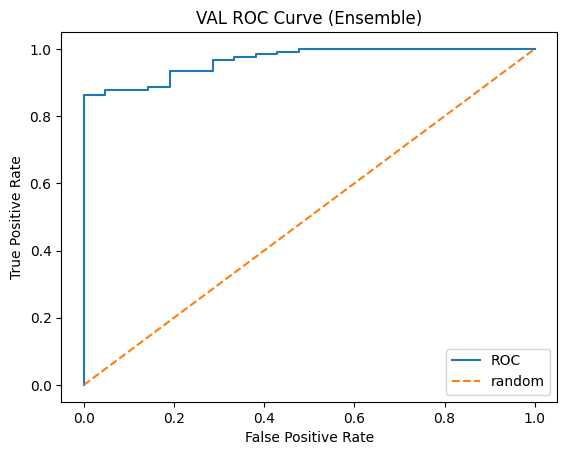

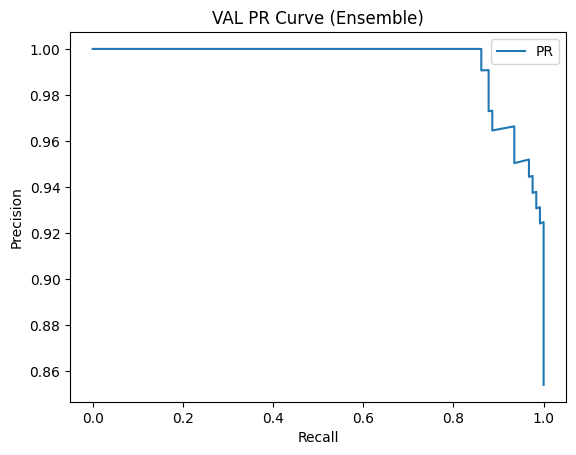

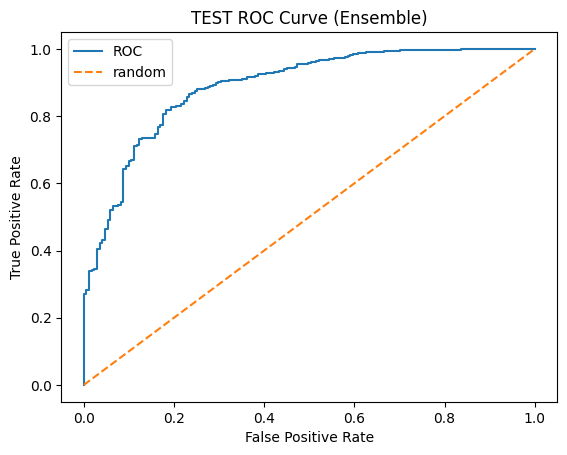

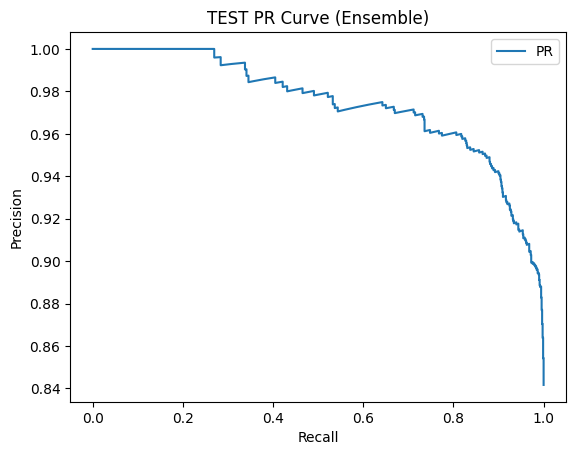


[VAL] Best threshold by balanced accuracy: t=0.50, balAcc=0.9268
[TEST @ best VAL threshold] loss=0.4437 balAcc=0.8112 rocAUC=0.8884 AP=0.9743

TEST @ best VAL threshold Confusion Matrix (rows=true, cols=pred):
[[132  39]
 [136 773]]
              precision    recall  f1-score   support

      class0     0.4925    0.7719    0.6014       171
      class1     0.9520    0.8504    0.8983       909

    accuracy                         0.8380      1080
   macro avg     0.7223    0.8112    0.7498      1080
weighted avg     0.8792    0.8380    0.8513      1080



In [25]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image

import torchvision.models as models
from torchvision import transforms
from torchvision.transforms import InterpolationMode

from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt

# -----------------------
# Reproducibility
# -----------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# -----------------------
# Transforms
# -----------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(
        224, scale=(0.7, 1.0),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# -----------------------
# Dataset
# -----------------------
class ISICBinaryDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, image_id):
        base = os.path.join(self.images_dir, str(image_id))
        for ext in [".jpg"]:
            p = base + ext
            if os.path.isfile(p):
                return p
        if os.path.isfile(base):
            return base
        raise FileNotFoundError(f"Image '{image_id}' not found in {self.images_dir}")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self._resolve_path(row["image"])
        y = int(row["label"])  # 0/1
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(y, dtype=torch.long)

# -----------------------
# Load splits
# -----------------------
train_df = pd.read_excel("train_binary_100.xlsx")
val_df   = pd.read_excel("val_binary.xlsx")
test_df  = pd.read_excel("test_binary.xlsx")

print("Shapes:", train_df.shape, val_df.shape, test_df.shape)

train_ds = ISICBinaryDataset(train_df, images_dir="train", transform=train_tfms)
val_ds   = ISICBinaryDataset(val_df,   images_dir="val",   transform=val_tfms)
test_ds  = ISICBinaryDataset(test_df,  images_dir="test",  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

# -----------------------
# Build models
# -----------------------
def build_resnet18():
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 2)
    return m

def build_mobilenetv3_small():
    m = models.mobilenet_v3_small(weights=None)
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, 2)
    return m

# -----------------------
# Load weights
# -----------------------
RESNET_W = "best_resnet18_fc_layer4_1_balacc.pth"
MOBILENET_W = "best_mobilenetv3_lastblock_balacc.pth"

resnet = build_resnet18()
resnet.load_state_dict(torch.load(RESNET_W, map_location=DEVICE))
resnet.to(DEVICE).eval()

mobilenet = build_mobilenetv3_small()
mobilenet.load_state_dict(torch.load(MOBILENET_W, map_location=DEVICE))
mobilenet.to(DEVICE).eval()

models_list = [resnet, mobilenet]
print("Loaded ensemble models:", [type(m).__name__ for m in models_list])

# -----------------------
# Loss weights (optional)
# -----------------------
y_train = train_df["label"].values
class_counts = np.bincount(y_train, minlength=2)
w0 = 1.0 / max(class_counts[0], 1)
w1 = 1.0 / max(class_counts[1], 1)
ce_weights = torch.tensor([w0, w1], dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=ce_weights)

# -----------------------
# Ensemble forward helper
# -----------------------
@torch.no_grad()
def ensemble_logits(models_list, imgs):
    logits_sum = 0.0
    for m in models_list:
        logits_sum = logits_sum + m(imgs)
    return logits_sum / len(models_list)

# -----------------------
# Eval that also returns probs for ROC/PR
# -----------------------
@torch.no_grad()
def ensemble_eval_full(models_list, loader, return_loss=False, threshold=0.5):
    y_true_list, y_pred_list, p1_list = [], [], []
    total_loss = 0.0

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = ensemble_logits(models_list, imgs)
        probs = torch.softmax(logits, dim=1)  # [B,2]
        p1 = probs[:, 1]  # prob of class 1

  
        preds = (p1 >= threshold).long()

        y_true_list.append(labels.detach().cpu().numpy())
        y_pred_list.append(preds.detach().cpu().numpy())
        p1_list.append(p1.detach().cpu().numpy())

        if return_loss:
            loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)

    y_true = np.concatenate(y_true_list) if len(y_true_list) else np.array([])
    y_pred = np.concatenate(y_pred_list) if len(y_pred_list) else np.array([])
    p1_all = np.concatenate(p1_list) if len(p1_list) else np.array([])

    metrics = {}
    metrics["bal_acc"] = balanced_accuracy_score(y_true, y_pred) if len(y_true) else float("nan")

    if return_loss:
        metrics["loss"] = total_loss / len(loader.dataset)

    # confusion matrix + report
    if len(y_true):
        metrics["cm"] = confusion_matrix(y_true, y_pred)
        metrics["report"] = classification_report(
            y_true, y_pred, digits=4, target_names=["class0", "class1"]
        )
    else:
        metrics["cm"] = None
        metrics["report"] = None

    # ROC-AUC (binary; needs both classes present)
    if len(y_true) and (len(np.unique(y_true)) == 2):
        metrics["roc_auc"] = roc_auc_score(y_true, p1_all)
        fpr, tpr, _ = roc_curve(y_true, p1_all)
        prec, rec, _ = precision_recall_curve(y_true, p1_all)
        metrics["roc_curve"] = (fpr, tpr)
        metrics["pr_curve"] = (prec, rec)
        metrics["ap"] = average_precision_score(y_true, p1_all)
    else:
        metrics["roc_auc"] = float("nan")
        metrics["roc_curve"] = None
        metrics["pr_curve"] = None
        metrics["ap"] = float("nan")

    return metrics, y_true, y_pred, p1_all


def plot_roc(fpr, tpr, title):
    plt.figure()
    plt.plot(fpr, tpr, label="ROC")
    plt.plot([0, 1], [0, 1], linestyle="--", label="random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_pr(prec, rec, title):
    plt.figure()
    plt.plot(rec, prec, label="PR")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.show()

def print_cm(cm, name):
    print(f"\n{name} Confusion Matrix (rows=true, cols=pred):")
    print(cm)


THRESH = 0.5

val_metrics, val_y, val_pred, val_p1 = ensemble_eval_full(models_list, val_loader, return_loss=True, threshold=THRESH)
test_metrics, test_y, test_pred, test_p1 = ensemble_eval_full(models_list, test_loader, return_loss=True, threshold=THRESH)

print("\nENSEMBLE RESULTS")
print(f"VAL  loss={val_metrics['loss']:.4f}  balAcc={val_metrics['bal_acc']:.4f}  rocAUC={val_metrics['roc_auc']:.4f}  AP={val_metrics['ap']:.4f}")
print(f"TEST loss={test_metrics['loss']:.4f} balAcc={test_metrics['bal_acc']:.4f} rocAUC={test_metrics['roc_auc']:.4f} AP={test_metrics['ap']:.4f}")

print_cm(val_metrics["cm"], "VAL")
print(val_metrics["report"])

print_cm(test_metrics["cm"], "TEST")
print(test_metrics["report"])


if val_metrics["roc_curve"] is not None:
    fpr, tpr = val_metrics["roc_curve"]
    plot_roc(fpr, tpr, "VAL ROC Curve (Ensemble)")
if val_metrics["pr_curve"] is not None:
    prec, rec = val_metrics["pr_curve"]
    plot_pr(prec, rec, "VAL PR Curve (Ensemble)")

if test_metrics["roc_curve"] is not None:
    fpr, tpr = test_metrics["roc_curve"]
    plot_roc(fpr, tpr, "TEST ROC Curve (Ensemble)")
if test_metrics["pr_curve"] is not None:
    prec, rec = test_metrics["pr_curve"]
    plot_pr(prec, rec, "TEST PR Curve (Ensemble)")



DO_SWEEP = True
if DO_SWEEP and len(val_y):
    thresholds = np.linspace(0.05, 0.95, 19)
    best_t, best_ba = None, -1.0

    for t in thresholds:
        preds = (val_p1 >= t).astype(np.int64)
        ba = balanced_accuracy_score(val_y, preds)
        if ba > best_ba:
            best_ba = ba
            best_t = float(t)

    print(f"\n[VAL] Best threshold by balanced accuracy: t={best_t:.2f}, balAcc={best_ba:.4f}")

   
    test_metrics2, _, _, _ = ensemble_eval_full(models_list, test_loader, return_loss=True, threshold=best_t)
    print(f"[TEST @ best VAL threshold] loss={test_metrics2['loss']:.4f} balAcc={test_metrics2['bal_acc']:.4f} rocAUC={test_metrics2['roc_auc']:.4f} AP={test_metrics2['ap']:.4f}")
    print_cm(test_metrics2["cm"], "TEST @ best VAL threshold")
    print(test_metrics2["report"])

In [26]:
import os
import io
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt



#grad cam
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def build_resnet18_for_binary():
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 2)
    return m

def build_mobilenetv3_small_for_binary():
    m = models.mobilenet_v3_small(weights=None)
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, 2)
    return m

RESNET_W = "best_resnet18_fc_layer4_1_balacc.pth"
MOBILENET_W = "best_mobilenetv3_lastblock_balacc.pth"

resnet = build_resnet18_for_binary()
resnet.load_state_dict(torch.load(RESNET_W, map_location=DEVICE))
resnet.to(DEVICE).eval()

mobilenet = build_mobilenetv3_small_for_binary()
mobilenet.load_state_dict(torch.load(MOBILENET_W, map_location=DEVICE))
mobilenet.to(DEVICE).eval()


class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._handles = []
        self._register_hooks()

    def _register_hooks(self):
        def fwd_hook(module, inp, out):
            self.activations = out.detach()

        def bwd_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self._handles.append(self.target_layer.register_forward_hook(fwd_hook))
        self._handles.append(self.target_layer.register_full_backward_hook(bwd_hook))

    def close(self):
        for h in self._handles:
            h.remove()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)

        logits = self.model(x)
        probs = torch.softmax(logits, dim=1)

        pred_class = int(torch.argmax(probs, dim=1).item())
        if class_idx is None:
            class_idx = pred_class

        score = logits[:, class_idx]
        score.backward()

        A = self.activations
        G = self.gradients

        weights = G.mean(dim=(2, 3), keepdim=True)
        cam = (weights * A).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = cam[0, 0]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return (
            cam.detach().cpu().numpy(),
            pred_class,
            probs.detach().cpu().numpy()[0]
        )


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def tensor_to_rgb(img_t: torch.Tensor) -> np.ndarray:
  
    img = img_t.detach().cpu()
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = img.clamp(0, 1)
    img = (img.permute(1,2,0).numpy() * 255).astype(np.uint8)
    return img

def render_and_write_png_to_zip(zf: zipfile.ZipFile, filename: str, rgb: np.ndarray, cam: np.ndarray,
                                title: str = ""):

    fig = plt.figure(figsize=(9, 3))
    ax1 = fig.add_subplot(1,3,1)
    ax2 = fig.add_subplot(1,3,2)
    ax3 = fig.add_subplot(1,3,3)

    ax1.imshow(rgb)
    ax1.set_title("Image")
    ax1.axis("off")

    ax2.imshow(cam, cmap="jet")
    ax2.set_title("Grad-CAM")
    ax2.axis("off")

    ax3.imshow(rgb)
    ax3.imshow(cam, cmap="jet", alpha=0.4)
    ax3.set_title("Overlay")
    ax3.axis("off")

    if title:
        fig.suptitle(title, fontsize=10)

    buf = io.BytesIO()
    plt.tight_layout()
    fig.savefig(buf, format="png", dpi=150)
    plt.close(fig)
    buf.seek(0)

    zf.writestr(filename, buf.read())


# ResNet: last block conv 
resnet_target_layer = resnet.layer4[-1].conv2  

mobilenet_target_layer = mobilenet.features[-1]

resnet_cam = GradCAM(resnet, resnet_target_layer)
mobilenet_cam = GradCAM(mobilenet, mobilenet_target_layer)



train_gradcam_ds = ISICBinaryDataset(train_df, images_dir="train", transform=val_tfms)

# If you want ordered, set shuffle=False
train_gradcam_loader = DataLoader(train_gradcam_ds, batch_size=1, shuffle=False, num_workers=0)

# ------------------------------------------------------------
# Run Grad-CAM on train 
# ------------------------------------------------------------
OUT_ZIP_RESNET = "gradcam_train_resnet18.zip"
OUT_ZIP_MOBILENET = "gradcam_train_mobilenetv3.zip"

N_SAMPLES = None   

def save_gradcam_zip(model_name: str, cam_engine: GradCAM, zip_path: str):
    n = 0
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for i, (img_t, y) in enumerate(train_gradcam_loader):
            if (N_SAMPLES is not None) and (n >= N_SAMPLES):
                break

            img_t = img_t.to(DEVICE)
            y_true = int(y.item())

            cam, pred_class, probs = cam_engine(img_t, class_idx=None)  
            rgb = tensor_to_rgb(img_t[0])

            p0, p1 = float(probs[0]), float(probs[1])
            fname = f"{i:05d}_y{y_true}_pred{pred_class}_p0{p0:.3f}_p1{p1:.3f}.png"
            title = f"{model_name} | y={y_true} pred={pred_class} p0={p0:.3f} p1={p1:.3f}"

            render_and_write_png_to_zip(zf, fname, rgb, cam, title=title)

            n += 1

    print(f"[OK] Saved {n} Grad-CAM images to: {zip_path}")

save_gradcam_zip("ResNet18", resnet_cam, OUT_ZIP_RESNET)
save_gradcam_zip("MobileNetV3", mobilenet_cam, OUT_ZIP_MOBILENET)

# cleanup hooks
resnet_cam.close()
mobilenet_cam.close()

C:\Users\Mohammad Pashaei\AppData\Local\Temp\ipykernel_11828\427926032.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet.load_state_dict(torch.load(RESNET_W, map_l

[OK] Saved 100 Grad-CAM images to: gradcam_train_resnet18.zip
[OK] Saved 100 Grad-CAM images to: gradcam_train_mobilenetv3.zip


In [27]:
import re
import zipfile
import numpy as np
from PIL import Image
from sklearn.metrics import jaccard_score
import pandas as pd

# -----------------------
# تنظیمات
# -----------------------
ZIP_RESNET = "gradcam_train_resnet18.zip"
ZIP_MOBILENET = "gradcam_train_mobilenetv3.zip"

IOU_THRESHOLD = 0.70

TOP_PCT = 30

PRINT_TOP_K = 10



def list_pngs(zip_path):
    with zipfile.ZipFile(zip_path, "r") as zf:
        return [n for n in zf.namelist() if n.lower().endswith(".png")]

def index_from_name(name: str):
    m = re.match(r"^(\d{5})_", name)
    return m.group(1) if m else None

def read_png_from_zip(zip_path, member_name):
    with zipfile.ZipFile(zip_path, "r") as zf:
        data = zf.read(member_name)
    img = Image.open(io.BytesIO(data)).convert("RGB")
    return img

def crop_middle_panel(rgb_img: np.ndarray):
 
    h, w, _ = rgb_img.shape
    x1 = w // 3
    x2 = 2 * w // 3
    mid = rgb_img[:, x1:x2, :]
    return mid

def auto_trim_whitespace(panel: np.ndarray, white_thr=245):

    # mask of non-white pixels
    nonwhite = np.any(panel < white_thr, axis=2)
    if nonwhite.sum() < 10:
        return panel  

    ys, xs = np.where(nonwhite)
    y1, y2 = ys.min(), ys.max()
    x1, x2 = xs.min(), xs.max()
    
    m = 3
    y1 = max(0, y1 - m); y2 = min(panel.shape[0]-1, y2 + m)
    x1 = max(0, x1 - m); x2 = min(panel.shape[1]-1, x2 + m)
    return panel[y1:y2+1, x1:x2+1, :]

def heatmap_to_score(panel: np.ndarray):

    panel = panel.astype(np.float32)
    R = panel[..., 0]
    G = panel[..., 1]
    B = panel[..., 2]
    denom = (R + G + B + 1e-6)
    score = (R + G - B) / denom
    # normalize 0..1
    score = score - score.min()
    score = score / (score.max() + 1e-8)
    return score

def score_to_mask(score: np.ndarray, top_pct=30):
    """
    mask = 1 for top_pct% pixels
    """
    thr = np.percentile(score, 100 - top_pct)
    return (score >= thr).astype(np.uint8)

def iou(mask_a: np.ndarray, mask_b: np.ndarray):
    """
    IoU = intersection / union
    """
    a = mask_a.reshape(-1).astype(np.uint8)
    b = mask_b.reshape(-1).astype(np.uint8)
    inter = np.logical_and(a == 1, b == 1).sum()
    union = np.logical_or(a == 1, b == 1).sum()
    return float(inter / (union + 1e-8))



import io

res_names = list_pngs(ZIP_RESNET)
mob_names = list_pngs(ZIP_MOBILENET)

res_map = {}
for n in res_names:
    idx = index_from_name(n)
    if idx is not None:
        res_map[idx] = n

mob_map = {}
for n in mob_names:
    idx = index_from_name(n)
    if idx is not None:
        mob_map[idx] = n

common = sorted(set(res_map.keys()) & set(mob_map.keys()))
print(f"ResNet PNGs: {len(res_names)} | MobileNet PNGs: {len(mob_names)} | Common IDs: {len(common)}")

rows = []
hits = 0

for idx in common:
    # read images
    with zipfile.ZipFile(ZIP_RESNET, "r") as zf:
        res_img = Image.open(io.BytesIO(zf.read(res_map[idx]))).convert("RGB")
    with zipfile.ZipFile(ZIP_MOBILENET, "r") as zf:
        mob_img = Image.open(io.BytesIO(zf.read(mob_map[idx]))).convert("RGB")

    res_np = np.array(res_img)
    mob_np = np.array(mob_img)

    # crop heatmap panel
    res_mid = crop_middle_panel(res_np)
    mob_mid = crop_middle_panel(mob_np)

    res_mid = auto_trim_whitespace(res_mid)
    mob_mid = auto_trim_whitespace(mob_mid)

    H = min(res_mid.shape[0], mob_mid.shape[0])
    W = min(res_mid.shape[1], mob_mid.shape[1])
    res_mid = np.array(Image.fromarray(res_mid).resize((W, H)))
    mob_mid = np.array(Image.fromarray(mob_mid).resize((W, H)))

    # score + mask
    res_score = heatmap_to_score(res_mid)
    mob_score = heatmap_to_score(mob_mid)

    res_mask = score_to_mask(res_score, top_pct=TOP_PCT)
    mob_mask = score_to_mask(mob_score, top_pct=TOP_PCT)

    val_iou = iou(res_mask, mob_mask)
    is_hit = val_iou >= IOU_THRESHOLD
    hits += int(is_hit)

    rows.append({
        "id": idx,
        "resnet_file": res_map[idx],
        "mobilenet_file": mob_map[idx],
        "iou": val_iou,
        "hit_iou_ge_0p70": int(is_hit),
        "top_pct_mask": TOP_PCT
    })

df = pd.DataFrame(rows).sort_values("iou", ascending=False)

print("\n==== RESULT ====")
print(f"IOU threshold: {IOU_THRESHOLD} | mask top%: {TOP_PCT}")
print(f"Hits (IoU>=0.70): {hits} / {len(common)}  ({(hits/max(len(common),1))*100:.2f}%)")

print("\nTop examples by IoU:")
print(df.head(PRINT_TOP_K)[["id", "iou", "hit_iou_ge_0p70"]].to_string(index=False))

out_csv = "gradcam_overlap_report.csv"
df.to_csv(out_csv, index=False)
print(f"\nSaved per-sample report: {out_csv}")

ResNet PNGs: 100 | MobileNet PNGs: 100 | Common IDs: 100

==== RESULT ====
IOU threshold: 0.7 | mask top%: 30
Hits (IoU>=0.70): 21 / 100  (21.00%)

Top examples by IoU:
   id      iou  hit_iou_ge_0p70
00035 0.813027                1
00096 0.800868                1
00056 0.769090                1
00039 0.763478                1
00017 0.756620                1
00051 0.749154                1
00060 0.746461                1
00085 0.744904                1
00002 0.744826                1
00028 0.743775                1

Saved per-sample report: gradcam_overlap_report.csv
